In [33]:
# Surface Wave Plots David Glacier Seismic
# Zachary Katz
# 11 December 2025

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from obspy.io.segy.core import _read_segy
import os
import pandas as pd
from scipy.signal import find_peaks
import scipy
import obspy

import numpy as np
import matplotlib.pyplot as plt
from obspy import read
import cmath

############
line = '21Y'
geometry_path = f'./_data/KPDC_David_Seismic_2022/RAW/{line}-Geometry.csv' 
sgy_file = f'./_data/KPDC_David_Seismic_2022/RAW/{line}'
num_shots = 20 # Number of shots on this Line [X=56, Y=40, XX=28. YY=20]
############

sgy_path = sgy_file + '.sgy'

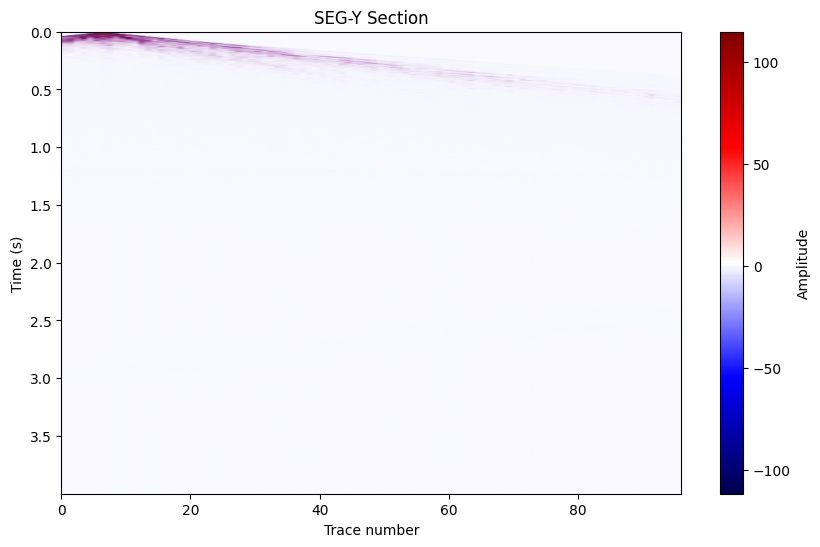

In [52]:
# Load segy
st = read(sgy_path, format="SEGY")
trace_chosen = 9
tracenum=96
data = np.array([tr.data for tr in st[trace_chosen*tracenum:(1+trace_chosen)*tracenum]]).T

dt = st[0].stats.delta  # sample interval (seconds)
nt, nx = data.shape

t = np.arange(nt) * dt

plt.figure(figsize=(10,6))
plt.imshow(data, aspect="auto", cmap="seismic",
           extent=[0, nx, t[-1], t[0]])
plt.xlabel("Trace number")
plt.ylabel("Time (s)")
plt.title("SEG-Y Section")
plt.colorbar(label="Amplitude")
plt.show()


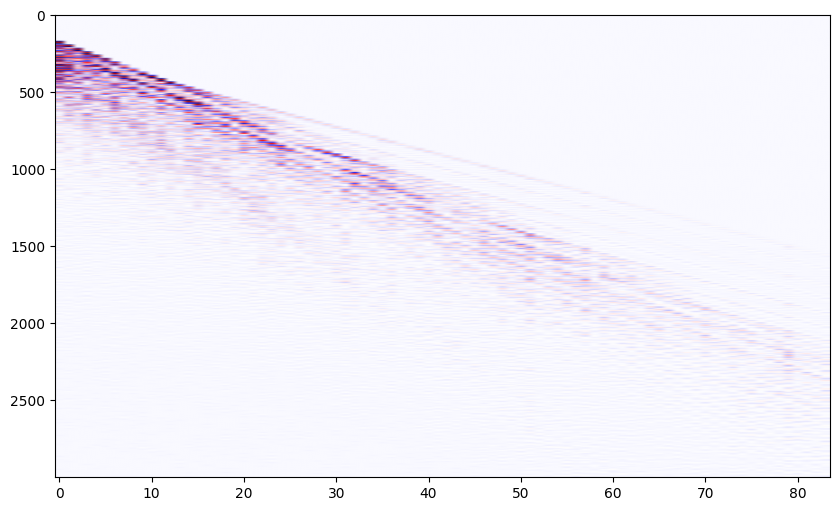

In [60]:
z = data
### CHANGE HERE TO ENSURE ONE SIDED GATHER
z = z[:3000, 12:] # One sided gather

dt = 0.00025  # seconds
trace_spacing = 15 # meters
off_min = 90  # minimum offset of your data

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(z, aspect='auto', cmap='seismic')

In [61]:
def importsegy(filepath):
    tmp = read(filepath, format="SEGY")
    tmp2 = tmp[0]
    data = np.zeros((len(tmp2.data), len(tmp)))
    for i, tr in enumerate(tmp):
        data[:, i] = tr.data
    return data

def importsu(filepath):
    traces = read(filepath)
    n_samples = len(traces[0].times("matplotlib"))
    n_traces = len(traces)
    data = np.zeros((n_samples, n_traces))
    for i, trace in enumerate(traces):
        data[:, i] = trace.data
    return data

def fft_ephase(data):
    # Perform FFT along the time axis (rows)
    dfft = np.fft.fft(data, axis=0)
    # Extract the phase angle of the FFT result and construct the complex exponential of the phase term
    phase = np.angle(dfft) 
    e_phase = np.exp(-1j * phase)

    # OR just normalize the FFT to get the complex exponential of the phase term
    e_phase = dfft / (np.abs(dfft))
    return dfft, phase, e_phase


def test_ephase(receiver_offset, F, C):
    # Compute phase shift in radians: (2πf/velocity) * offset) or (omega * offset)
    phase_t = (2 * np.pi * F ) / C

    # Compute complex exponential of the phase term (IF USING normalization to get e_phase)
    e_phase_t = np.power(np.exp(1j * phase_t),receiver_offset)

    # Compute complex exponential of the phase term (IF USING np.phase angle to get e_phase)
    # e_phase_t = np.power(np.exp(-1j * phase_t),receiver_offset)

    return phase_t, e_phase_t

#z = data_cut #importsegy(sgy_path) # 'one-sided' shot gather i.e. only positive or only negative offsets

data = z # np.fliplr(z) # flip if negative offsets


no_samples, no_traces = data.shape
offsets = np.arange(off_min, off_min + trace_spacing * no_traces, trace_spacing)

###########################################################################################
print("FFT")
dfft, ph, eph = fft_ephase(data)
freq = np.fft.fftfreq(no_samples, d=dt)

# Apply fftshift so freq runs from negative → positive
dfft_all = np.fft.fftshift(dfft, axes=0)
ph_all = np.fft.fftshift(ph, axes=0)
eph_all = np.fft.fftshift(eph, axes=0)
freq_all = np.fft.fftshift(freq)

###########################################################################################
print("Mesh")
c_step = 1
c_range = np.arange(800, 2800 + c_step , c_step)  # Test range for velocities --- you may need to adjust this
F, C = np.meshgrid(freq_all, c_range)

###########################################################################################
print("Stack")
dp={}
for e, o in enumerate(offsets[:]):
    print(f"Offset {e}, {o}")
    ph_t, eph_t = test_ephase(o,F,C)
    dp[e] = eph_all[:,e] * eph_t

stack = sum(dp[key] for key in dp)
A = (np.abs( stack / len(dp) ))

FFT
Mesh
Stack
Offset 0, 90
Offset 1, 105
Offset 2, 120
Offset 3, 135
Offset 4, 150
Offset 5, 165
Offset 6, 180
Offset 7, 195
Offset 8, 210
Offset 9, 225
Offset 10, 240
Offset 11, 255
Offset 12, 270
Offset 13, 285
Offset 14, 300
Offset 15, 315
Offset 16, 330
Offset 17, 345
Offset 18, 360
Offset 19, 375
Offset 20, 390
Offset 21, 405
Offset 22, 420
Offset 23, 435
Offset 24, 450
Offset 25, 465
Offset 26, 480
Offset 27, 495
Offset 28, 510
Offset 29, 525
Offset 30, 540
Offset 31, 555
Offset 32, 570
Offset 33, 585
Offset 34, 600
Offset 35, 615
Offset 36, 630
Offset 37, 645
Offset 38, 660
Offset 39, 675
Offset 40, 690
Offset 41, 705
Offset 42, 720
Offset 43, 735
Offset 44, 750
Offset 45, 765
Offset 46, 780
Offset 47, 795
Offset 48, 810
Offset 49, 825
Offset 50, 840
Offset 51, 855
Offset 52, 870
Offset 53, 885
Offset 54, 900
Offset 55, 915
Offset 56, 930
Offset 57, 945
Offset 58, 960
Offset 59, 975
Offset 60, 990
Offset 61, 1005
Offset 62, 1020
Offset 63, 1035
Offset 64, 1050
Offset 65, 1065
O

Plot


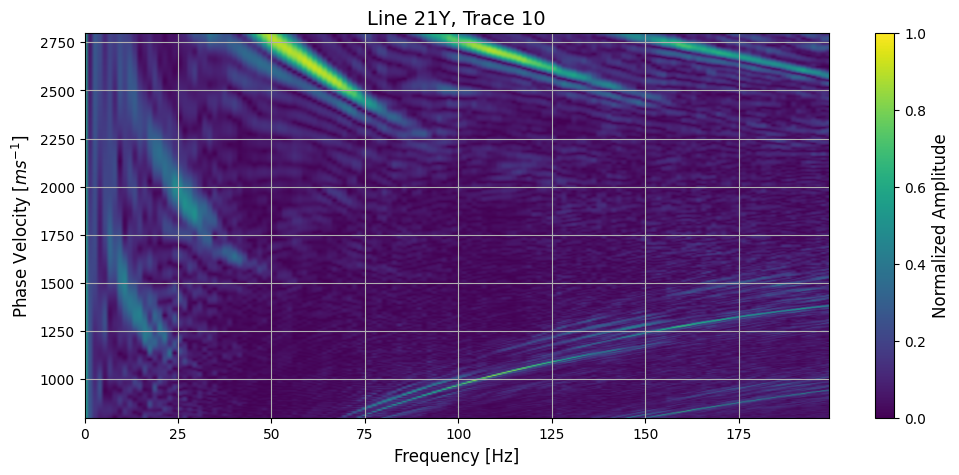

: 

In [ ]:
    
print("Plot")
fig, ax = plt.subplots(figsize=(12, 5))
cp = ax.imshow(
    A,
    extent=[F.min(), F.max(), C.min(), C.max()],
    origin='lower',
    aspect='auto',
    cmap='viridis',
    vmin=0,
    vmax=1
)
cb = fig.colorbar(cp)
cb.set_label('Normalized Amplitude', fontsize=12)
ax.set_xlabel('Frequency [Hz]', fontsize=12)
ax.set_ylabel('Phase Velocity [$m s^{-1}$]', fontsize=12)
ax.set_title(f"Line {line}, Trace {trace_chosen + 1}", fontsize=14)
ax.set_xlim(0,199)
ax.grid()
fig.savefig(f"{line}_Trace{trace_chosen + 1}_DispersionPanel.png", dpi=300)


In [ ]:
# Subsetting option
st_subset = obspy.Stream(traces=st[96:2*96])
st_subset.write("21YY_2.sgy", format="SEGY")